In [1]:
import sys, os, importlib
print(sys.path)

PATH_ROOT    = "/root/workspace/Python/flipd/"
PATH_MODEL   = "/root/workspace/Python/flipd/notebooks/outputs/notebooks/"
PATH_DATASET = "/root/workspace/Python/flipd/notebooks/dataset/"
PATH_FIG   = "/root/workspace/Python/flipd/notebooks/figs/EigenDist/"
os.chdir(PATH_ROOT)
!pwd


['/root/workspace/Python/flipd/notebooks', '/opt/conda/lib/python310.zip', '/opt/conda/lib/python3.10', '/opt/conda/lib/python3.10/lib-dynload', '', '/opt/conda/lib/python3.10/site-packages', '/opt/conda/lib/python3.10/site-packages/setuptools/_vendor']
/root/workspace/Python/flipd


In [2]:
import math
import numpy as np
import torch
from torch import nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm, trange
import matplotlib.pyplot as plt

from diffusers import DDPMPipeline

torch.set_grad_enabled(True)
torch.manual_seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype  = torch.float32

MODEL_ID = "google/ddpm-cifar10-32"

# ── SLQ / pooled-Ritz defaults (fast, qualitative) ─────────────────────────────
SPEC_T              = 2         # timestep to probe
SPEC_NUM_IMAGES     = 256        # increase for smoother shape
SPEC_BATCH_SIZE     = 32
SPEC_NUM_PROBES     = 4          # random starts per image
SPEC_LANCZOS_STEPS  = 30         # Krylov steps (more = sharper)


2025-11-29 14:33:24.884616: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-29 14:33:24.898538: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-29 14:33:24.915212: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-29 14:33:24.920335: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-29 14:33:24.932683: I tensorflow/core/platform/cpu_feature_guar

In [3]:
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")

In [4]:
def make_cifar10_loader(split="train", num_images=None, batch_size=32):
    tfm = transforms.Compose([
        transforms.ToTensor(),
        transforms.Lambda(lambda x: x * 2 - 1)  # [-1,1]
    ])
    ds = datasets.CIFAR10(root=PATH_DATASET, train=(split=="train"),
                          download=True, transform=tfm)
    if num_images is not None:
        ds = torch.utils.data.Subset(ds, list(range(min(num_images, len(ds)))))
    return DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

@torch.no_grad()
def get_alpha_sigma_from_scheduler(scheduler, t_idx, device):
    # x_t = sqrt(alpha_bar) x0 + sqrt(1-alpha_bar) eps
    alpha_bar = scheduler.alphas_cumprod[t_idx].to(device)
    alpha = torch.sqrt(alpha_bar)
    sigma = torch.sqrt(1.0 - alpha_bar)
    return alpha, sigma


In [5]:
class ScoreFromDDPM(nn.Module):
    """
    s_theta(x_t,t) ≈ ∇_{x_t} log p_t(x_t) via VP/DDPM relation: s ≈ -ε̂ / σ_t
    """
    def __init__(self, pipeline):
        super().__init__()
        self.unet = pipeline.unet
        self.scheduler = pipeline.scheduler
        for p in self.unet.parameters():
            p.requires_grad_(False)

    def forward(self, x_t, t_index):
        if isinstance(t_index, int):
            t = torch.full((x_t.shape[0],), t_index, device=x_t.device, dtype=torch.long)
        else:
            t = t_index.to(x_t.device, dtype=torch.long)
        with torch.no_grad():
            _, sigma_t = get_alpha_sigma_from_scheduler(self.scheduler, t[0].item(), x_t.device)
            sigma_t = sigma_t.view(1,1,1,1)
        eps_pred = self.unet(x_t, t).sample
        return -eps_pred / sigma_t


In [6]:
def hessian_vector_product(score_fn, x_t, t_index, v):
    """
    H v where H = ∇_x s_theta(x,t) = ∇^2_x log p_t(x_t).
    H v = ∇_x ( s(x) · v ).
    """
    x_t = x_t.requires_grad_(True)
    s   = score_fn(x_t, t_index)
    dot = (s * v).sum()
    (Hv,) = torch.autograd.grad(dot, x_t, retain_graph=True, create_graph=False)
    return Hv
    

In [7]:
def lanczos_batch(score_fn, x_t, t_index, m_steps: int, v0: torch.Tensor | None = None):
    """
    Batched (per-image) Lanczos for symmetric H provided via HVP.
    Returns:
      alphas: (B, m_steps)
      betas : (B, m_steps-1)
    """
    B = x_t.shape[0]
    def norm_per_img(z): return z.flatten(1).norm(dim=1).clamp_min(1e-12)

    v = torch.randn_like(x_t) if v0 is None else v0.clone()
    v = v / norm_per_img(v).view(B,1,1,1)

    alphas, betas = [], []
    v_prev = torch.zeros_like(v)
    beta_prev = torch.zeros(B, device=x_t.device, dtype=x_t.dtype)

    for j in range(m_steps):
        Hv = hessian_vector_product(score_fn, x_t, t_index, v)
        w  = Hv - beta_prev.view(B,1,1,1) * v_prev

        alpha_j = (v.flatten(1) * w.flatten(1)).sum(dim=1)     # (B,)
        alphas.append(alpha_j)

        w = w - alpha_j.view(B,1,1,1) * v

        beta_j = norm_per_img(w)
        if j < m_steps - 1: betas.append(beta_j)

        v_prev = v
        v = w / beta_j.view(B,1,1,1)

        # handle breakdowns by reseeding
        mask = (beta_j < 1e-10)
        if mask.any():
            v_rand = torch.randn_like(v)
            v_rand = v_rand / norm_per_img(v_rand).view(B,1,1,1)
            v[mask] = v_rand[mask]

        beta_prev = beta_j

    alphas = torch.stack(alphas, dim=1)                   # (B, m)
    betas  = torch.stack(betas,  dim=1) if len(betas) else None  # (B, m-1)
    return alphas, betas


In [8]:
def ritz_eigs_from_tridiag(alphas: torch.Tensor, betas: torch.Tensor) -> np.ndarray:
    """
    Returns (B, m) Ritz eigenvalues from the m×m tridiagonal.
    """
    B, m = alphas.shape
    eigs = np.empty((B, m), dtype=np.float64)
    a = alphas.detach().cpu().numpy()
    b = betas.detach().cpu().numpy() if betas is not None else None

    for i in range(B):
        Ti = np.zeros((m, m), dtype=np.float64)
        np.fill_diagonal(Ti, a[i])
        if m > 1:
            np.fill_diagonal(Ti[1:], b[i])
            np.fill_diagonal(Ti[:,1:], b[i])
        eigs[i] = np.linalg.eigvalsh(Ti)
    return eigs


In [9]:
def spectral_sample_points_for_batch(score_fn, x_t, t_index, m_steps, num_probes):
    pooled = []
    for _ in range(num_probes):
        al, be = lanczos_batch(score_fn, x_t, t_index, m_steps=m_steps, v0=None)
        eigs = ritz_eigs_from_tridiag(al, be)       # (B, m_steps)
        pooled.append(eigs.reshape(-1))
    return np.concatenate(pooled, axis=0)

def estimate_spectrum_distribution(
    pipe, score_fn,
    t_index: int = SPEC_T,
    num_images: int = SPEC_NUM_IMAGES,
    batch_size: int = SPEC_BATCH_SIZE,
    num_probes: int = SPEC_NUM_PROBES,
    m_steps: int = SPEC_LANCZOS_STEPS,
    split: str = "train",
):
    loader = make_cifar10_loader(split=split, num_images=num_images, batch_size=batch_size)
    all_eigs = []
    for x0, _ in tqdm(loader, desc=f"SLQ spectrum @ t={t_index}"):
        x0 = x0.to(device=device, dtype=dtype)
        eps = torch.randn_like(x0)
        with torch.no_grad():
            alpha_bar = pipe.scheduler.alphas_cumprod[t_index].to(device)
            x_t = torch.sqrt(alpha_bar) * x0 + torch.sqrt(1.0 - alpha_bar) * eps

        pts = spectral_sample_points_for_batch(score_fn, x_t.detach().clone(), t_index,
                                              m_steps=m_steps, num_probes=num_probes)
        all_eigs.append(pts)
    return np.concatenate(all_eigs, axis=0)


In [10]:
pipe = DDPMPipeline.from_pretrained(MODEL_ID, torch_dtype=dtype).to(device)
pipe.unet.eval()
score_fn = ScoreFromDDPM(pipe).to(device)


Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--google--ddpm-cifar10-32/snapshots/267b167dc01f0e4e61923ea244e8b988f84deb80: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--google--ddpm-cifar10-32/snapshots/267b167dc01f0e4e61923ea244e8b988f84deb80.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Files already downloaded and verified


SLQ spectrum @ t=2: 100%|██████████| 8/8 [00:35<00:00,  4.46s/it]


Collected 30,720 Ritz eigenvalue samples.
mean=-1002.7267, std=1965.2345, min=-19245.4216, max=21650.5592


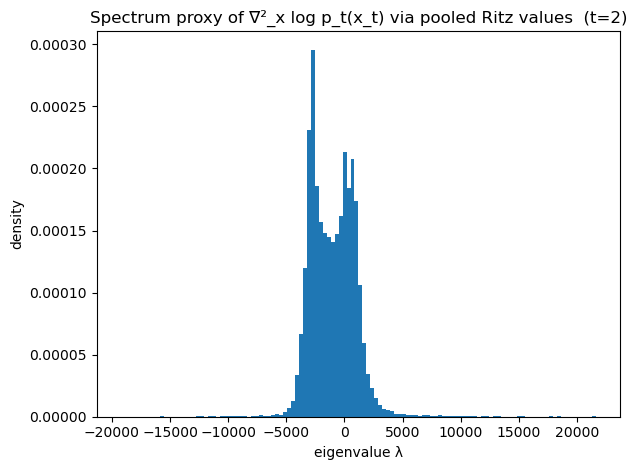

In [11]:
spec_points = estimate_spectrum_distribution(
    pipe, score_fn,
    t_index=SPEC_T,
    num_images=SPEC_NUM_IMAGES,
    batch_size=SPEC_BATCH_SIZE,
    num_probes=SPEC_NUM_PROBES,
    m_steps=SPEC_LANCZOS_STEPS,
)

print(f"Collected {spec_points.size:,} Ritz eigenvalue samples.")
print(f"mean={spec_points.mean():.4f}, std={spec_points.std():.4f}, "
      f"min={spec_points.min():.4f}, max={spec_points.max():.4f}")

plt.figure()
plt.hist(spec_points, bins=120, density=True)
plt.title(f"Spectrum proxy of ∇²_x log p_t(x_t) via pooled Ritz values  (t={SPEC_T})")
plt.xlabel("eigenvalue λ"); plt.ylabel("density"); plt.tight_layout(); plt.show()
